# 📊  Análisis de Datos viviendas en Estados Unidos

---

**Autor:** Jesus Gustavo Camacho Olivos  
**Año de venta:** Abril 2026  
**Versión:** 1.0  

---

## 📌 1. Introducción del Proyecto

### 🎯 Descripción del Problema

Este proyecto analiza el dataset **House Prices** para entender qué factores explican mejor el precio de venta de las viviendas.

---

### 🎯 Objetivos del Análisis

1. **Objetivo Principal:** Identificar los factores clave que impactan en `SalePrice`.
2. **Objetivos Específicos:**
   - Analizar la distribución de las variables principales de vivienda.
   - Identificar diferencias de precio por vecindario y tipo de vivienda.
   - Detectar outliers y relaciones no lineales relevantes.
   - Construir conclusiones accionables para modelado predictivo.

---

### ❓ Preguntas Clave a Responder

- ¿Qué variables estructurales se relacionan más con `SalePrice`?
- ¿Qué vecindarios presentan mayores y menores precios medianos?
- ¿Existen patrones temporales por año o mes de venta?
- ¿Qué tan influyente es la calidad general de la vivienda?
- ¿Qué transformaciones o variables derivadas mejoran el análisis?

---


## 📦 2. Importación de Librerías

Configuramos el entorno de trabajo con las librerías necesarias para el análisis.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estadística y análisis
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Utilidades
import warnings
from datetime import datetime, timedelta
import os

# Configuraciones generales
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"📌 Pandas version: {pd.__version__}")
print(f"📌 NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
📌 Pandas version: 3.0.2
📌 NumPy version: 2.4.4


## 📥 3. Carga de Datos

### 📂 Opciones de Carga de Datos

A continuación se presentan diferentes métodos para cargar datos según la fuente.

In [2]:
# Cargar desde archivo CSV
# Archivo por defecto para el analisis principal
ruta_datos = 'train.csv'

try:
    df = pd.read_csv(ruta_datos, encoding='utf-8')
    print("✅ Datos cargados exitosamente")
    print(
        f"📊 Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(
        f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo en '{ruta_datos}'")
    print("💡 Sugerencia: Verifica la ruta o coloca el archivo train.csv en el mismo directorio del notebook")
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")

✅ Datos cargados exitosamente
📊 Dimensiones del dataset: 1,460 filas x 81 columnas
💾 Tamaño en memoria: 3.43 MB


### 👀 Vista Preliminar de los Datos

In [3]:
# Primeras filas
print("🔍 Primeras 5 filas del dataset:\n")
display(df.head())

print("\n" + "="*80 + "\n")

# Últimas filas
print("🔍 Últimas 5 filas del dataset:\n")
display(df.tail())

🔍 Primeras 5 filas del dataset:



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




🔍 Últimas 5 filas del dataset:



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.00,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.00,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.00,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.00,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.00,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.00,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.00,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.00,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.00,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.00,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.00,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.00,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.00,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
# Información general del dataset
print("📋 Información General del Dataset:\n")
df.info()

print("\n" + "="*80 + "\n")

# Muestra aleatoria
print("🎲 Muestra aleatoria de 5 registros:\n")
display(df.sample(5))

📋 Información General del Dataset:

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nul

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1281,1282,20,RL,50.00,8049,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Timber,Norm,Norm,1Fam,1Story,7,5,1990,1990,Hip,CompShg,HdBoard,HdBoard,BrkFace,54.00,TA,TA,CBlock,Gd,TA,No,ALQ,1053,Unf,0,256,1309,GasA,TA,Y,SBrkr,1339,0,0,1339,1,0,2,0,2,1,TA,6,Typ,1,TA,Attchd,1990.00,Fin,2,484,Gd,Gd,Y,0,58,0,0,90,0,NaN,NaN,NaN,0,7,2006,WD,Normal,180000
314,315,70,RM,60.00,9600,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,7,7,1925,1990,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,LwQ,16,Unf,0,712,728,GasA,Ex,Y,SBrkr,832,809,0,1641,0,1,1,1,3,1,Ex,6,Typ,1,Gd,Detchd,1925.00,Unf,2,546,Fa,TA,Y,0,0,234,0,0,0,NaN,NaN,NaN,0,8,2006,WD,Normal,178000
599,600,160,RM,24.00,1950,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Blueste,Norm,Norm,Twnhs,2Story,6,6,1980,1980,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,Gd,CBlock,Gd,TA,No,LwQ,81,GLQ,612,23,716,GasA,TA,Y,SBrkr,716,840,0,1556,1,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1980.00,Fin,2,452,TA,TA,Y,161,0,0,0,0,0,NaN,GdPrv,NaN,0,7,2008,COD,Normal,151000
835,836,20,RL,60.00,9600,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,4,7,1950,1995,Gable,CompShg,VinylSd,HdBoard,NaN,0.00,TA,TA,CBlock,Gd,TA,No,BLQ,442,Unf,0,625,1067,GasA,TA,Y,SBrkr,1067,0,0,1067,0,0,2,0,2,1,Gd,4,Min2,0,NaN,Attchd,1996.00,Unf,2,436,TA,TA,Y,290,0,0,0,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal,128000
1073,1074,60,RL,75.00,7950,Pave,NaN,IR1,Bnk,AllPub,Corner,Gtl,Edwards,Norm,Norm,1Fam,2Story,6,6,1977,1977,Hip,CompShg,HdBoard,Plywood,BrkFace,140.00,TA,TA,CBlock,TA,TA,No,BLQ,535,Unf,0,155,690,GasA,TA,Y,SBrkr,698,728,0,1426,0,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1977.00,Fin,2,440,TA,TA,Y,252,0,0,0,0,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,159500


## 🧹 4. Limpieza y Preparación de Datos

### 🔍 Análisis de Calidad de Datos

In [5]:
# Resumen de calidad de datos
def analizar_calidad_datos(df):
    """
    Genera un reporte completo de la calidad de los datos
    """
    calidad = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        '%_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Únicos': df.nunique(),
        'Duplicados': df.duplicated().sum()
    })

    return calidad.sort_values('%_Nulos', ascending=False)


print("📊 Reporte de Calidad de Datos:\n")
reporte_calidad = analizar_calidad_datos(df)
display(reporte_calidad)

print(f"\n⚠️ Total de filas duplicadas: {df.duplicated().sum()}")
print(
    f"✅ Porcentaje de completitud general: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

📊 Reporte de Calidad de Datos:



,Tipo_Dato,Valores_Nulos,%_Nulos,Valores_Únicos,Duplicados
PoolQC,str,1453,99.52,3,0
MiscFeature,str,1406,96.30,4,0
Alley,str,1369,93.77,2,0
Fence,str,1179,80.75,4,0
MasVnrType,str,872,59.73,3,0
FireplaceQu,str,690,47.26,5,0
LotFrontage,float64,259,17.74,110,0
GarageQual,str,81,5.55,5,0
GarageFinish,str,81,5.55,3,0
GarageType,str,81,5.55,6,0



⚠️ Total de filas duplicadas: 0
✅ Porcentaje de completitud general: 93.38%


### 🧼 Manejo de Valores Nulos

In [6]:
# Estrategias para valores nulos
print("🔧 Aplicando estrategias para valores nulos...\n")

# Opción 1: Eliminar filas con valores nulos (si son pocas)
# df_clean = df.dropna()

# Opción 2: Rellenar con mediana/media para variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con mediana ({mediana:.2f})")

# Opción 3: Rellenar con moda para variables categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con moda ('{moda}')")

print(f"\n✨ Valores nulos restantes: {df.isnull().sum().sum()}")

🔧 Aplicando estrategias para valores nulos...

✅ Columna 'LotFrontage': 259 nulos rellenados con mediana (69.00)
✅ Columna 'MasVnrArea': 8 nulos rellenados con mediana (0.00)
✅ Columna 'GarageYrBlt': 81 nulos rellenados con mediana (1980.00)


✅ Columna 'Alley': 1369 nulos rellenados con moda ('Grvl')
✅ Columna 'MasVnrType': 872 nulos rellenados con moda ('BrkFace')
✅ Columna 'BsmtQual': 37 nulos rellenados con moda ('TA')
✅ Columna 'BsmtCond': 37 nulos rellenados con moda ('TA')
✅ Columna 'BsmtExposure': 38 nulos rellenados con moda ('No')
✅ Columna 'BsmtFinType1': 37 nulos rellenados con moda ('Unf')
✅ Columna 'BsmtFinType2': 38 nulos rellenados con moda ('Unf')
✅ Columna 'Electrical': 1 nulos rellenados con moda ('SBrkr')
✅ Columna 'FireplaceQu': 690 nulos rellenados con moda ('Gd')
✅ Columna 'GarageType': 81 nulos rellenados con moda ('Attchd')
✅ Columna 'GarageFinish': 81 nulos rellenados con moda ('Unf')
✅ Columna 'GarageQual': 81 nulos rellenados con moda ('TA')
✅ Columna 'GarageCond': 81 nulos rellenados con moda ('TA')
✅ Columna 'PoolQC': 1453 nulos rellenados con moda ('Gd')
✅ Columna 'Fence': 1179 nulos rellenados con moda ('MnPrv')
✅ Columna 'MiscFeature': 1406 nulos rellenados con moda ('Shed')

✨ Valores nulos 

### 🗑️ Eliminación de Duplicados

In [7]:
# Identificar y eliminar duplicados
print(f"🔍 Filas duplicadas encontradas: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df_before = len(df)
    df = df.drop_duplicates()
    df_after = len(df)
    print(f"✅ Se eliminaron {df_before - df_after} filas duplicadas")
else:
    print("✅ No se encontraron duplicados")

print(f"\n📊 Dimensiones actuales: {df.shape}")

🔍 Filas duplicadas encontradas: 0
✅ No se encontraron duplicados

📊 Dimensiones actuales: (1460, 81)


### 🔄 Conversión de Tipos de Datos

In [8]:
# Convertir tipos de datos según sea necesario
print("🔄 Ajustando tipos de datos...\n")

# Convertir fechas si existen
if 'YrSold' in df.columns:
    df['YrSold'] = pd.to_datetime(df['YrSold'])
    print("✅ Columna 'YrSold' convertida a datetime")

# Convertir categorías para optimizar memoria
for col in columnas_categoricas:
    if df[col].nunique() / len(df) < 0.5:  # Si tiene menos del 50% de valores únicos
        df[col] = df[col].astype('category')
        print(f"✅ Columna '{col}' convertida a tipo category")

print("\n📋 Tipos de datos actualizados:")
print(df.dtypes)

🔄 Ajustando tipos de datos...

✅ Columna 'YrSold' convertida a datetime
✅ Columna 'MSZoning' convertida a tipo category


✅ Columna 'Street' convertida a tipo category
✅ Columna 'Alley' convertida a tipo category
✅ Columna 'LotShape' convertida a tipo category
✅ Columna 'LandContour' convertida a tipo category
✅ Columna 'Utilities' convertida a tipo category
✅ Columna 'LotConfig' convertida a tipo category
✅ Columna 'LandSlope' convertida a tipo category
✅ Columna 'Neighborhood' convertida a tipo category
✅ Columna 'Condition1' convertida a tipo category
✅ Columna 'Condition2' convertida a tipo category
✅ Columna 'BldgType' convertida a tipo category
✅ Columna 'HouseStyle' convertida a tipo category
✅ Columna 'RoofStyle' convertida a tipo category
✅ Columna 'RoofMatl' convertida a tipo category
✅ Columna 'Exterior1st' convertida a tipo category
✅ Columna 'Exterior2nd' convertida a tipo category
✅ Columna 'MasVnrType' convertida a tipo category
✅ Columna 'ExterQual' convertida a tipo category
✅ Columna 'ExterCond' convertida a tipo category
✅ Columna 'Foundation' convertida a tipo category
✅ Columna 'BsmtQ

### 🎯 Detección y Tratamiento de Outliers

In [9]:
def detectar_outliers_iqr(df, columna):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) |
                  (df[columna] > limite_superior)]

    return outliers, limite_inferior, limite_superior


# Analizar outliers en variables numéricas principales
print("🔍 Análisis de Outliers:\n")

for col in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea']:
    if col in df.columns:
        outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
        print(f"📊 {col}:")
        print(
            f"   • Outliers detectados: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")
        print(f"   • Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]")
        print()

# Decidir estrategia: eliminar, winsorizar o mantener
# Opción 1: Eliminar outliers extremos
# df = df[~df.index.isin(outliers.index)]

# Opción 2: Winsorización (reemplazar outliers con límites)
# df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

print("✅ Análisis de outliers completado")

🔍 Análisis de Outliers:

📊 SalePrice:
   • Outliers detectados: 61 (4.18%)
   • Rango normal: [3937.50, 340037.50]

📊 GrLivArea:
   • Outliers detectados: 31 (2.12%)
   • Rango normal: [158.62, 2747.62]

📊 LotArea:
   • Outliers detectados: 69 (4.73%)
   • Rango normal: [1481.50, 17673.50]

📊 TotalBsmtSF:
   • Outliers detectados: 61 (4.18%)
   • Rango normal: [42.00, 2052.00]

📊 GarageArea:
   • Outliers detectados: 21 (1.44%)
   • Rango normal: [-27.75, 938.25]

✅ Análisis de outliers completado


### ➕ Creación de Variables Derivadas

In [13]:
# Crear variables útiles para el análisis de viviendas
print("➕ Creando variables derivadas para House Prices...\n")

# Utilidad: extraer el año como número aunque la columna venga como datetime o texto
# (evita errores al restar fechas contra enteros como YearBuilt).
def _to_year_numeric(serie):
    if pd.api.types.is_datetime64_any_dtype(serie):
        return serie.dt.year
    return pd.to_numeric(serie, errors='coerce')

# 1) Variables temporales a partir del año de venta
if 'YrSold' in df.columns:
    yr_sold = _to_year_numeric(df['YrSold'])

    if 'YearBuilt' in df.columns:
        year_built = _to_year_numeric(df['YearBuilt'])
        df['antiguedad_venta'] = yr_sold - year_built

    if 'YearRemodAdd' in df.columns:
        year_remod = _to_year_numeric(df['YearRemodAdd'])
        df['anios_desde_remodelacion'] = yr_sold - year_remod

    print("✅ Variables temporales creadas: antiguedad_venta, anios_desde_remodelacion")

# 2) Superficie total util (sotano + pisos superiores)
area_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
if all(col in df.columns for col in area_cols):
    df['superficie_total'] = (
        pd.to_numeric(df['TotalBsmtSF'], errors='coerce').fillna(0)
        + pd.to_numeric(df['1stFlrSF'], errors='coerce').fillna(0)
        + pd.to_numeric(df['2ndFlrSF'], errors='coerce').fillna(0)
    )
    print("✅ Variable 'superficie_total' creada")

# 3) Total de banos ponderado (banos completos + 0.5 * medios banos)
bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
if all(col in df.columns for col in bath_cols):
    df['banos_totales'] = (
        pd.to_numeric(df['FullBath'], errors='coerce').fillna(0)
        + 0.5 * pd.to_numeric(df['HalfBath'], errors='coerce').fillna(0)
        + pd.to_numeric(df['BsmtFullBath'], errors='coerce').fillna(0)
        + 0.5 * pd.to_numeric(df['BsmtHalfBath'], errors='coerce').fillna(0)
    )
    print("✅ Variable 'banos_totales' creada")

# 4) Calidad total simplificada (combinacion de calidad y estado)
if 'OverallQual' in df.columns and 'OverallCond' in df.columns:
    df['calidad_total'] = (
        pd.to_numeric(df['OverallQual'], errors='coerce')
        + pd.to_numeric(df['OverallCond'], errors='coerce')
    )
    print("✅ Variable 'calidad_total' creada")

# 5) Categorizacion de precio de venta (objetivo)
if 'SalePrice' in df.columns:
    saleprice_num = pd.to_numeric(df['SalePrice'], errors='coerce')
    df['categoria_precio'] = pd.qcut(
        saleprice_num,
        q=3,
        labels=['Bajo', 'Medio', 'Alto'],
        duplicates='drop'
    )
    print("✅ Variable 'categoria_precio' creada")

print(f"\n📊 Nuevas dimensiones del dataset: {df.shape}")



➕ Creando variables derivadas para House Prices...



TypeError: Addition/subtraction of integers and integer-arrays with DatetimeArray is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

## 🔍 5. Análisis Exploratorio de Datos (EDA)

### 📈 Estadísticas Descriptivas Generales

In [ ]:
# Estadísticas descriptivas completas
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas\n")
print("="*80)

estadisticas = df.describe().T
# Coeficiente de variación
estadisticas['cv'] = (estadisticas['std'] / estadisticas['mean']) * 100
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']

display(estadisticas)

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas\n")
display(df.describe(include=['object', 'category']))

📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas



,count,mean,std,min,25%,50%,75%,max,cv,rango
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00,57.72,1459.00
MSSubClass,1460.00,56.90,42.30,20.00,20.00,50.00,70.00,190.00,74.35,170.00
LotFrontage,1201.00,70.05,24.28,21.00,59.00,69.00,80.00,313.00,34.67,292.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00,94.91,213945.00
OverallQual,1460.00,6.10,1.38,1.00,5.00,6.00,7.00,10.00,22.67,9.00
OverallCond,1460.00,5.58,1.11,1.00,5.00,5.00,6.00,9.00,19.96,8.00
YearBuilt,1460.00,1971.27,30.20,1872.00,1954.00,1973.00,2000.00,2010.00,1.53,138.00
YearRemodAdd,1460.00,1984.87,20.65,1950.00,1967.00,1994.00,2004.00,2010.00,1.04,60.00
MasVnrArea,1452.00,103.69,181.07,0.00,0.00,0.00,166.00,1600.00,174.63,1600.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00,102.81,5644.00



📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas



,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


### 📊 Análisis de Distribución de Variables Numéricas

In [ ]:
# Análisis de distribución con histogramas y estadísticas
def analizar_distribucion(df, columna):
    """
    Analiza la distribución de una variable numérica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de Distribución: {columna}")
    print(f"{'='*60}\n")

    # Estadísticas
    print(f"Media: {df[columna].mean():.2f}")
    print(f"Mediana: {df[columna].median():.2f}")
    print(f"Moda: {df[columna].mode()[0]:.2f}")
    print(f"Desviación Estándar: {df[columna].std():.2f}")
    print(f"Asimetría (Skewness): {skew(df[columna].dropna()):.2f}")
    print(f"Curtosis: {kurtosis(df[columna].dropna()):.2f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(df[columna].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(df[columna].mean(), color='red',
                    linestyle='--', label=f'Media: {df[columna].mean():.2f}')
    axes[0].axvline(df[columna].median(), color='green',
                    linestyle='--', label=f'Mediana: {df[columna].median():.2f}')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    axes[1].boxplot(df[columna].dropna(), vert=True)
    axes[1].set_title(f'Boxplot de {columna}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(columna)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Analizar variables clave
for col in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea']:
    if col in df.columns:
        analizar_distribucion(df, col)

### 🔗 Análisis de Correlaciones

🔗 MATRIZ DE CORRELACIÓN



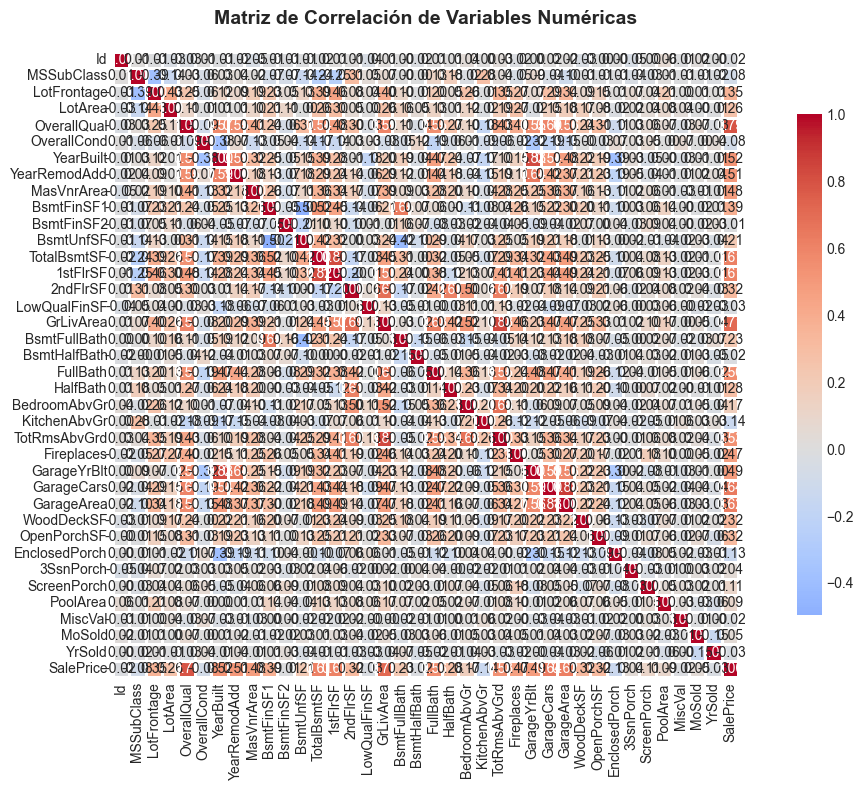


🔍 Correlaciones más fuertes (|r| > 0.5):



,Variable 1,Variable 2,Correlación
35,GarageCars,GarageArea,0.88
10,YearBuilt,GarageYrBlt,0.83
27,GrLivArea,TotRmsAbvGrd,0.83
17,TotalBsmtSF,1stFlrSF,0.82
8,OverallQual,SalePrice,0.79
28,GrLivArea,SalePrice,0.71
21,2ndFlrSF,GrLivArea,0.69
31,BedroomAbvGr,TotRmsAbvGrd,0.68
16,BsmtFinSF1,BsmtFullBath,0.65
13,YearRemodAdd,GarageYrBlt,0.64


In [ ]:
# Matriz de correlación
print("🔗 MATRIZ DE CORRELACIÓN\n")

# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calcular correlaciones
correlacion = df_numeric.corr()

# Visualización con heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n🔍 Correlaciones más fuertes (|r| > 0.5):\n")
correlaciones_fuertes = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.5:
            correlaciones_fuertes.append({
                'Variable 1': correlacion.columns[i],
                'Variable 2': correlacion.columns[j],
                'Correlación': correlacion.iloc[i, j]
            })

if correlaciones_fuertes:
    df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values(
        'Correlación', ascending=False)
    display(df_corr_fuertes)
else:
    print("No se encontraron correlaciones fuertes (|r| > 0.5)")

### 📊 Análisis Univariado - Variables Categóricas

In [ ]:
# Análisis de frecuencias de variables categóricas
def analizar_categorica(df, columna):
    """
    Analiza la distribución de una variable categórica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de: {columna}")
    print(f"{'='*60}\n")

    # Tabla de frecuencias
    freq_table = pd.DataFrame({
        'Frecuencia': df[columna].value_counts(),
        'Porcentaje': (df[columna].value_counts(normalize=True) * 100).round(2)
    })
    display(freq_table)

    # Gráfico de barras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    freq_table['Frecuencia'].plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_xlabel(columna)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)

    # Gráfico de pastel
    axes[1].pie(freq_table['Frecuencia'],
                labels=freq_table.index,
                autopct='%1.1f%%',
                startangle=90)
    axes[1].set_title(f'Proporción de {columna}',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Analizar variables categóricas principales
for col in ['Neighborhood', 'HouseStyle']:
    if col in df.columns:
        analizar_categorica(df, col)

### 🔄 Análisis Bivariado - Relaciones entre Variables

In [ ]:
# Análisis de relación entre variables numéricas y categóricas
print("🔍 ANÁLISIS BIVARIADO")
print()

# Precio de venta por vecindario
if 'SalePrice' in df.columns and 'Neighborhood' in df.columns:
    print("📊 Estadísticas de precio de venta por vecindario:")
    print()
    precio_vecindario = df.groupby('Neighborhood')['SalePrice'].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count']
    )
    precio_vecindario.columns = ['Media', 'Mediana', 'Desv_Est', 'Mínimo', 'Máximo', 'Cantidad']
    display(precio_vecindario.sort_values('Media', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Boxplot por vecindario
    df.boxplot(column='SalePrice', by='Neighborhood', ax=axes[0])
    axes[0].set_title('Distribución de SalePrice por vecindario', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Vecindario')
    axes[0].set_ylabel('Precio de venta')
    plt.sca(axes[0])
    plt.xticks(rotation=45)

    # Barras de promedio por vecindario
    precio_vecindario['Media'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Precio promedio por vecindario', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Precio promedio')
    axes[1].set_xlabel('Vecindario')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


🔍 ANÁLISIS BIVARIADO



In [ ]:
# Scatter plot para relaciones entre dos variables numéricas
if 'GrLivArea' in df.columns and 'SalePrice' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, edgecolors='black')
    plt.title('Relación entre GrLivArea y SalePrice', fontsize=14, fontweight='bold')
    plt.xlabel('Superficie habitable (GrLivArea)')
    plt.ylabel('Precio de venta (SalePrice)')
    plt.grid(True, alpha=0.3)

    # Línea de tendencia
    temp = df[['GrLivArea', 'SalePrice']].dropna()
    if len(temp) > 1:
        z = np.polyfit(temp['GrLivArea'], temp['SalePrice'], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(temp['GrLivArea'])
        plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, label='Tendencia')
        plt.legend()

    plt.tight_layout()
    plt.show()


### 📅 Análisis Temporal (si aplica)

In [ ]:
# Análisis de series temporales
if 'SalePrice' in df.columns and 'YrSold' in df.columns:
    print("📅 ANÁLISIS TEMPORAL DE PRECIOS")
    print()

    df_temp = df.copy()
    df_temp['yr'] = pd.to_numeric(df_temp['YrSold'], errors='coerce')
    if 'MoSold' in df_temp.columns:
        df_temp['mo'] = pd.to_numeric(df_temp['MoSold'], errors='coerce')
    else:
        df_temp['mo'] = 1

    df_temp = df_temp.dropna(subset=['yr', 'mo', 'SalePrice'])
    if not df_temp.empty:
        df_temp['yr'] = df_temp['yr'].astype(int)
        df_temp['mo'] = df_temp['mo'].astype(int).clip(1, 12)
        df_temp['periodo'] = pd.to_datetime(dict(year=df_temp['yr'], month=df_temp['mo'], day=1), errors='coerce')
        df_temp = df_temp.dropna(subset=['periodo'])

        serie = df_temp.groupby('periodo')['SalePrice'].agg(['sum', 'mean', 'count']).sort_index()

        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        axes[0].plot(serie.index, serie['sum'], marker='o', linewidth=2)
        axes[0].set_title('Evolución mensual del precio total de ventas', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Suma mensual de SalePrice')
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)

        axes[1].plot(serie.index, serie['mean'], marker='s', color='green', linewidth=2)
        axes[1].set_title('Evolución mensual del precio promedio de venta', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Promedio mensual de SalePrice')
        axes[1].set_xlabel('Periodo')
        axes[1].grid(True, alpha=0.3)
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

        # Estacionalidad por mes
        precio_por_mes = df_temp.groupby('mo')['SalePrice'].mean().reindex(range(1, 13))
        plt.figure(figsize=(12, 6))
        precio_por_mes.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title('Estacionalidad: SalePrice promedio por mes', fontsize=14, fontweight='bold')
        plt.xlabel('Mes')
        plt.ylabel('Precio promedio')
        plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()


## 📊 6. Visualización de Datos Avanzada

### 🎨 Visualizaciones Interactivas con Plotly

In [ ]:
# Gráfico interactivo de dispersión con Plotly
if all(col in df.columns for col in ['GrLivArea', 'SalePrice', 'Neighborhood']):
    size_col = 'superficie_total' if 'superficie_total' in df.columns else None
    hover_cols = [c for c in ['HouseStyle', 'OverallQual', 'OverallCond'] if c in df.columns]

    fig = px.scatter(
        df,
        x='GrLivArea',
        y='SalePrice',
        color='Neighborhood',
        size=size_col,
        hover_data=hover_cols,
        title='Análisis multidimensional: GrLivArea vs SalePrice por vecindario',
        labels={'GrLivArea': 'Superficie habitable', 'SalePrice': 'Precio de venta'},
        template='plotly_white'
    )

    fig.update_layout(height=600, font=dict(size=12), title_font=dict(size=16, family='Arial Black'))
    fig.show()


In [ ]:
# Gráfico de barras agrupadas interactivo
if all(col in df.columns for col in ['Neighborhood', 'HouseStyle', 'SalePrice']):
    precio_grouped = df.groupby(['Neighborhood', 'HouseStyle'])['SalePrice'].mean().reset_index()

    fig = px.bar(
        precio_grouped,
        x='Neighborhood',
        y='SalePrice',
        color='HouseStyle',
        title='Precio promedio por vecindario y estilo de vivienda',
        labels={'SalePrice': 'Precio promedio', 'Neighborhood': 'Vecindario', 'HouseStyle': 'Estilo'},
        barmode='group',
        template='plotly_white'
    )

    fig.update_layout(height=500, font=dict(size=12), title_font=dict(size=16, family='Arial Black'))
    fig.show()


In [ ]:
# Gráfico de línea temporal interactivo
if 'YrSold' in df.columns and 'SalePrice' in df.columns:
    df_line = df.copy()
    df_line['yr'] = pd.to_numeric(df_line['YrSold'], errors='coerce')
    if 'MoSold' in df_line.columns:
        df_line['mo'] = pd.to_numeric(df_line['MoSold'], errors='coerce')
    else:
        df_line['mo'] = 1

    df_line = df_line.dropna(subset=['yr', 'mo', 'SalePrice'])
    if not df_line.empty:
        df_line['yr'] = df_line['yr'].astype(int)
        df_line['mo'] = df_line['mo'].astype(int).clip(1, 12)
        df_line['periodo'] = pd.to_datetime(dict(year=df_line['yr'], month=df_line['mo'], day=1), errors='coerce')
        df_line = df_line.dropna(subset=['periodo'])

        df_monthly = df_line.groupby('periodo')['SalePrice'].mean().reset_index()

        fig = px.line(
            df_monthly,
            x='periodo',
            y='SalePrice',
            title='Evolución mensual del precio promedio de venta',
            labels={'periodo': 'Periodo', 'SalePrice': 'Precio promedio'},
            template='plotly_white'
        )

        fig.update_traces(line_color='#1f77b4', line_width=2)
        fig.update_layout(
            height=500,
            font=dict(size=12),
            title_font=dict(size=16, family='Arial Black'),
            hovermode='x unified'
        )

        fig.show()


In [ ]:
# Mapa de calor interactivo
if all(col in df.columns for col in ['Neighborhood', 'SalePrice', 'MoSold']):
    mes_col = pd.to_numeric(df['MoSold'], errors='coerce').astype('Int64')

    temp = df.copy()
    temp['mes_plot'] = mes_col
    temp = temp.dropna(subset=['mes_plot', 'SalePrice'])

    heatmap_data = temp.pivot_table(
        values='SalePrice',
        index='Neighborhood',
        columns='mes_plot',
        aggfunc='mean'
    )

    fig = px.imshow(
        heatmap_data,
        labels=dict(x='Mes', y='Vecindario', color='Precio promedio'),
        title='Mapa de calor: precio promedio por vecindario y mes',
        color_continuous_scale='RdYlGn',
        aspect='auto'
    )

    fig.update_layout(height=500, font=dict(size=12), title_font=dict(size=16, family='Arial Black'))
    fig.show()



### 📈 Dashboard de Múltiples Métricas

In [ ]:
# Crear un dashboard con múltiples subplots
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Precio promedio por vecindario',
        'Distribución de SalePrice',
        'Top 10 viviendas por precio',
        'Tendencia temporal del precio promedio'
    ),
    specs=[[{'type': 'bar'}, {'type': 'box'}], [{'type': 'bar'}, {'type': 'scatter'}]]
)

# Gráfico 1: Precio promedio por vecindario
if all(col in df.columns for col in ['Neighborhood', 'SalePrice']):
    precio_vec = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
    fig.add_trace(go.Bar(x=precio_vec.index, y=precio_vec.values, name='Precio por vecindario'), row=1, col=1)

# Gráfico 2: Boxplot de precios
if 'SalePrice' in df.columns:
    fig.add_trace(go.Box(y=df['SalePrice'], name='Distribución de SalePrice'), row=1, col=2)

# Gráfico 3: Top 10 viviendas por precio
if all(col in df.columns for col in ['Id', 'SalePrice']):
    top_viviendas = df[['Id', 'SalePrice']].dropna().sort_values('SalePrice', ascending=False).head(10)
    fig.add_trace(
        go.Bar(x=top_viviendas['Id'].astype(str), y=top_viviendas['SalePrice'], name='Top 10 precios'),
        row=2, col=1
    )

# Gráfico 4: Tendencia temporal
if 'YrSold' in df.columns and 'SalePrice' in df.columns:
    df_t = df.copy()
    df_t['yr'] = pd.to_numeric(df_t['YrSold'], errors='coerce')
    if 'MoSold' in df_t.columns:
        df_t['mo'] = pd.to_numeric(df_t['MoSold'], errors='coerce')
    else:
        df_t['mo'] = 1
    df_t = df_t.dropna(subset=['yr', 'mo', 'SalePrice'])
    if not df_t.empty:
        df_t['yr'] = df_t['yr'].astype(int)
        df_t['mo'] = df_t['mo'].astype(int).clip(1, 12)
        df_t['periodo'] = pd.to_datetime(dict(year=df_t['yr'], month=df_t['mo'], day=1), errors='coerce')
        serie = df_t.dropna(subset=['periodo']).groupby('periodo')['SalePrice'].mean()
        fig.add_trace(go.Scatter(x=serie.index, y=serie.values, mode='lines', name='Tendencia'), row=2, col=2)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text='Dashboard de análisis de precios de viviendas',
    title_font=dict(size=18, family='Arial Black')
)

fig.show()


## 🧠 7. Insights y Conclusiones

### 🔑 Hallazgos Principales

In [ ]:
# Conclusiones automáticas del EDA
from IPython.display import display, Markdown

if 'SalePrice' in df.columns:
    sale = pd.to_numeric(df['SalePrice'], errors='coerce').dropna()

    media = sale.mean()
    mediana = sale.median()
    q1 = sale.quantile(0.25)
    q3 = sale.quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = ((sale < lim_inf) | (sale > lim_sup)).sum()
    outliers_pct = (outliers / len(sale)) * 100 if len(sale) else np.nan

    skewness = sale.skew()
    if skewness > 0.5:
        sesgo = 'sesgo positivo (cola a la derecha)'
    elif skewness < -0.5:
        sesgo = 'sesgo negativo (cola a la izquierda)'
    else:
        sesgo = 'distribución aproximadamente simétrica'

    texto = [
        "## ✅ Conclusiones automáticas del EDA",
        "",
        "### 📊 Comportamiento general de `SalePrice`",
        f"- **Promedio:** {media:,.2f}",
        f"- **Mediana:** {mediana:,.2f}",
        f"- **Rango intercuartílico (IQR):** {iqr:,.2f}",
        f"- **Distribución:** {sesgo}",
        f"- **Outliers (método IQR):** {outliers} ({outliers_pct:.2f}%)",
    ]

    if 'Neighborhood' in df.columns:
        precio_vec = df.groupby('Neighborhood')['SalePrice'].median().dropna().sort_values(ascending=False)
        if not precio_vec.empty:
            top_n = precio_vec.index[0]
            low_n = precio_vec.index[-1]
            brecha_pct = ((precio_vec.iloc[0] / precio_vec.iloc[-1]) - 1) * 100 if precio_vec.iloc[-1] != 0 else np.nan
            texto += [
                "",
                "### 🏘️ Segmentación por vecindario",
                f"- **Mayor precio mediano:** `{top_n}` ({precio_vec.iloc[0]:,.2f})",
                f"- **Menor precio mediano:** `{low_n}` ({precio_vec.iloc[-1]:,.2f})",
                f"- **Brecha entre extremos:** {brecha_pct:.2f}%",
            ]

    if all(col in df.columns for col in ['GrLivArea', 'SalePrice']):
        temp = df[['GrLivArea', 'SalePrice']].dropna()
        if len(temp) > 1:
            corr = temp['GrLivArea'].corr(temp['SalePrice'])
            texto += [
                "",
                "### 🔗 Relación clave",
                f"- **Correlación `GrLivArea` vs `SalePrice`:** {corr:.3f}",
            ]

    if all(col in df.columns for col in ['YrSold', 'SalePrice']):
        t = df.copy()
        t['yr'] = pd.to_numeric(t['YrSold'], errors='coerce')
        t = t.dropna(subset=['yr', 'SalePrice'])
        if not t.empty:
            yearly = t.groupby(t['yr'].astype(int))['SalePrice'].mean().sort_index()
            if len(yearly) >= 2:
                change_pct = ((yearly.iloc[-1] / yearly.iloc[0]) - 1) * 100 if yearly.iloc[0] != 0 else np.nan
                tendencia = 'creciente' if change_pct > 1 else ('decreciente' if change_pct < -1 else 'estable')
                texto += [
                    "",
                    "### 📈 Tendencia temporal",
                    f"- **Cambio del precio promedio** entre {yearly.index[0]} y {yearly.index[-1]}: {change_pct:.2f}%",
                    f"- **Tendencia general:** {tendencia}",
                ]

    texto += [
        "",
        "### 🎯 Recomendación para modelado",
        "- Aplicar transformación logarítmica a `SalePrice` (ej. `np.log1p`) para reducir asimetría.",
        "- Priorizar variables estructurales y de ubicación (`GrLivArea`, `OverallQual`, `Neighborhood`).",
    ]

    display(Markdown('\n'.join(texto)))
else:
    print("No se encontró la columna 'SalePrice' en el DataFrame actual.")




## 🎯 9. Exportación y Conexión a Herramientas BI

### 💾 Exportación de Datos Procesados

In [ ]:
# Exportar datos limpios a diferentes formatos
print("💾 Exportando datos procesados...\n")

# 1. Exportar a CSV
df.to_csv('datos_procesados.csv', index=False, encoding='utf-8-sig')
print("✅ Archivo CSV exportado: datos_procesados.csv")

# 2. Exportar a Excel con formato
with pd.ExcelWriter('analisis_completo.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Datos', index=False)

    # Agregar hoja con resumen estadístico
    df.describe().to_excel(writer, sheet_name='Resumen_Estadístico')

    # Agregar hoja con correlaciones
    df.select_dtypes(include=[np.number]).corr().to_excel(
        writer, sheet_name='Correlaciones')

print("✅ Archivo Excel exportado: analisis_completo.xlsx")

# 3. Exportar resumen para dashboards
resumen_dashboard = df.groupby(['Neighborhood', 'HouseStyle']).agg({
    'SalePrice': ['sum', 'mean', 'count'],
    'GrLivArea': 'sum',
    'superficie_total': 'sum'
}).round(2)

resumen_dashboard.to_csv('resumen_dashboard.csv', encoding='utf-8-sig')
print("✅ Resumen para dashboard exportado: resumen_dashboard.csv")

print("\n✨ Exportación completada exitosamente")

💾 Exportando datos procesados...

✅ Archivo CSV exportado: datos_procesados.csv


ModuleNotFoundError: No module named 'openpyxl'

### 📊 Integración con Power BI

#### Opciones de conexión

**1. Importación directa de archivos:**
```python
# Los archivos CSV exportados pueden importarse directamente en Power BI
# Archivo > Obtener datos > CSV
```

**2. Conexión a base de datos:**
```python
# Exportar a base de datos SQL para conexión dinámica
# from sqlalchemy import create_engine
# engine = create_engine('sqlite:///house_prices.db')
# df.to_sql('house_prices', engine, if_exists='replace', index=False)
```

**3. Conectar vía API:**
- Crear endpoint REST API
- Conectar Power BI mediante Web API

#### Métricas DAX recomendadas para Power BI

```dax
// Precio total de ventas
Precio_Total = SUM(Datos[SalePrice])

// Precio promedio de venta
Precio_Promedio = AVERAGE(Datos[SalePrice])

// Variación interanual (YoY)
Crecimiento_YoY =
DIVIDE(
    [Precio_Total] - CALCULATE([Precio_Total], SAMEPERIODLASTYEAR(Datos[FechaVenta])),
    CALCULATE([Precio_Total], SAMEPERIODLASTYEAR(Datos[FechaVenta]))
)

// Top 10 vecindarios por precio total
Top_10_Vecindarios =
CALCULATE(
    [Precio_Total],
    TOPN(10, ALL(Datos[Neighborhood]), [Precio_Total], DESC)
)
```

> Nota: en Power BI crea `FechaVenta` como fecha válida usando `YrSold` y `MoSold` para habilitar funciones de inteligencia de tiempo.

---


## 📚 Documentación y Referencias

### 📖 Recursos Utilizados

- **Pandas:** https://pandas.pydata.org/docs/
- **Matplotlib:** https://matplotlib.org/stable/contents.html
- **Seaborn:** https://seaborn.pydata.org/
- **Plotly:** https://plotly.com/python/
- **Scikit-learn:** https://scikit-learn.org/stable/

### 🔗 Enlaces Útiles

- **Mejores prácticas de visualización:** https://www.storytellingwithdata.com/
- **Curso de análisis de datos:** https://www.datacamp.com/
- **Comunidad de Data Science:** https://www.kaggle.com/

---

### ✍️ Notas del Analista

*Espacio para agregar observaciones, comentarios o contexto adicional relevante para futuras consultas.*

---

**Fin del análisis**  
**Preparado por:** Jesus Gustavo Camacho Olivos  
**Año de venta:** Abril 2026  
**Versión:** 1.0

---